# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Iris Flower Classification using the same Lab 5 workflow

### Lab focus
This version applies the **same Lab 5 workflow and student-task structure** to the Iris flower dataset used earlier. The original Lab 5 uses an order-status target and Talabat-specific columns; here, equivalent feature-engineering ideas are adapted to Iris features while keeping the same modeling approach.

### Objective
Build a baseline model to predict `species` and learn how feature engineering choices affect model performance and feature importance.

We will:
1) Load and inspect the Iris dataset
2) Define the target and usable predictors
3) Engineer new features
4) Encode categorical features where applicable
5) Train a baseline **Random Forest** classifier
6) Interpret performance and feature importance
7) Complete the student tasks from the original Lab 5


## 1. Setup and imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

The Iris dataset is the different dataset used in this version of Lab 5. It contains four numeric flower measurements and the target species.

In [ ]:
# Use the Iris dataset from the earlier labs.
iris = load_iris(as_frame=True)
df = iris.frame.copy()

df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])

df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


The dataset loaded correctly. Each row represents one flower and `species` is the classification target.

## 3. Quick dataset checks (cleanliness confirmation)

In [ ]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (150, 5)

Missing values per column:


,sepal_length,sepal_width,petal_length,petal_width,species
missing_count,0,0,0,0,0



Duplicate rows: 1


We confirm that the Iris dataset is clean, so the focus remains on feature engineering rather than data cleaning.

## 4. Target variable and class balance

In [ ]:
target_col = "species"
df[target_col].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

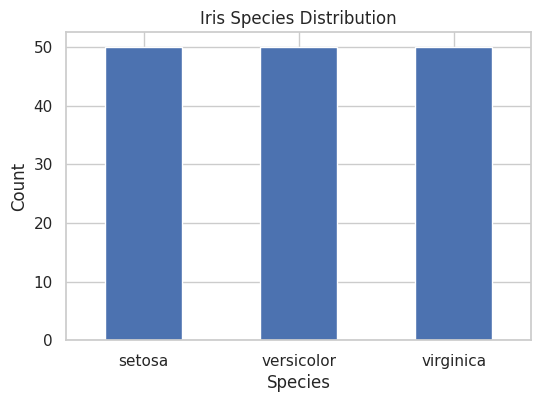

In [ ]:
plt.figure(figsize=(6,4))
df[target_col].value_counts().plot(kind="bar")
plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


The three Iris classes are balanced. Accuracy can therefore be interpreted together with the classification report and confusion matrix.

## 5. Identify feature types

In [ ]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

The original Iris predictors are numeric. The engineered `size_category` feature will be categorical and will therefore demonstrate the same One-Hot Encoding step used in the original Lab 5.

## 6. Leakage awareness (important)

The target is `species`. We do not use the original target label as an input feature. All predictors are flower measurements or features derived only from those measurements.

## 7. Feature engineering

### 7.1 Size and interaction features

Instead of Talabat-specific time features, we create flower-specific features that capture relationships among measurements: `petal_area`, `sepal_area`, and `petal_to_sepal_ratio`.

In [ ]:
df_fe = df.copy()

df_fe["petal_area"] = df_fe["petal_length"] * df_fe["petal_width"]
df_fe["sepal_area"] = df_fe["sepal_length"] * df_fe["sepal_width"]
df_fe["petal_to_sepal_ratio"] = df_fe["petal_length"] / df_fe["sepal_length"]

display(df_fe[["petal_length","petal_width","petal_area","sepal_area","petal_to_sepal_ratio"]].head(10))

,petal_length,petal_width,petal_area,sepal_area,petal_to_sepal_ratio
0,1.4,0.2,0.28,17.85,0.274510
1,1.4,0.2,0.28,14.70,0.285714
2,1.3,0.2,0.26,15.04,0.276596
3,1.5,0.2,0.30,14.26,0.326087
4,1.4,0.2,0.28,18.00,0.280000
5,1.7,0.4,0.68,21.06,0.314815
6,1.4,0.3,0.42,15.64,0.304348
7,1.5,0.2,0.30,17.00,0.300000
8,1.4,0.2,0.28,12.76,0.318182
9,1.5,0.1,0.15,15.19,0.306122


These engineered features summarize flower size and the relative size of the petal compared with the sepal.

### 7.2 Discretization / categorical feature

We create `petal_size_category` from `petal_area`. This plays the same feature-engineering role as the original lab’s price tiers: a continuous measurement is converted into meaningful categories.

In [ ]:
df_fe["petal_size_category"] = pd.qcut(
    df_fe["petal_area"],
    q=3,
    labels=["small", "medium", "large"],
    duplicates="drop"
)

display(df_fe[["petal_area","petal_size_category"]].head(10))

,petal_area,petal_size_category
0,0.28,small
1,0.28,small
2,0.26,small
3,0.30,small
4,0.28,small
5,0.68,small
6,0.42,small
7,0.30,small
8,0.28,small
9,0.15,small


### 7.3 Reducing categories

Iris does not contain a high-cardinality item-name column. To keep the same idea as the original Lab 5, we use the categorical engineered feature and test different category/bin rules in Task 3 rather than inventing a fake text field.

## 8. Prepare features for modeling

In [ ]:
drop_cols = [target_col]
X = df_fe.drop(columns=drop_cols)
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (150, 8)
y shape: (150,)


,sepal_length,sepal_width,petal_length,petal_width,petal_area,sepal_area,petal_to_sepal_ratio,petal_size_category
0,5.1,3.5,1.4,0.2,0.28,17.85,0.274510,small
1,4.9,3.0,1.4,0.2,0.28,14.70,0.285714,small
2,4.7,3.2,1.3,0.2,0.26,15.04,0.276596,small
3,4.6,3.1,1.5,0.2,0.30,14.26,0.326087,small
4,5.0,3.6,1.4,0.2,0.28,18.00,0.280000,small


We prepared the feature matrix `X` and target vector `y`, including both original and engineered Iris features.

## 9. Split into train and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120, 8)
Test size: (30, 8)


We use stratified splitting so the class proportions remain consistent in training and testing data.

## 10. Encoding and baseline model (Random Forest)

In [ ]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
)

model = Pipeline(steps=[("preprocess", preprocess), ("rf", rf)])
model

Categorical columns: ['petal_size_category']
Numeric columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'petal_area', 'sepal_area', 'petal_to_sepal_ratio']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

Random Forest is retained from the original Lab 5 because it handles numeric and encoded categorical features and provides feature importance.

## 11. Train the model and evaluate

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



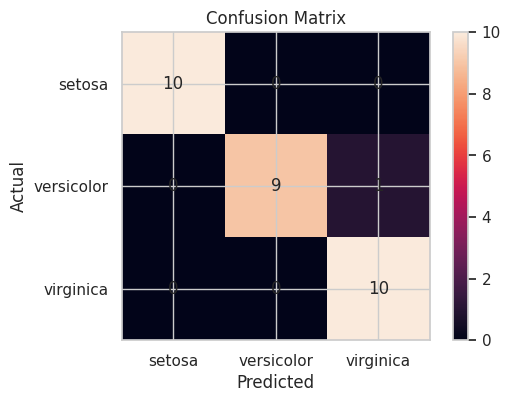

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(model.classes_)), model.classes_)
plt.yticks(range(len(model.classes_)), model.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


Accuracy, precision, recall, F1-score, and the confusion matrix are used to evaluate the classifier.

## 12. Feature importance (What mattered the most?)

In [ ]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if categorical_cols else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_
fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
      .sort_values("importance", ascending=False))

display(fi.head(15))

,feature,importance
7,petal_area,0.216671
6,petal_width,0.191704
5,petal_length,0.172257
9,petal_to_sepal_ratio,0.152716
2,petal_size_category_small,0.111517
0,petal_size_category_large,0.069811
1,petal_size_category_medium,0.054979
3,sepal_length,0.017853
8,sepal_area,0.006934
4,sepal_width,0.005557


<Figure size 800x500 with 0 Axes>

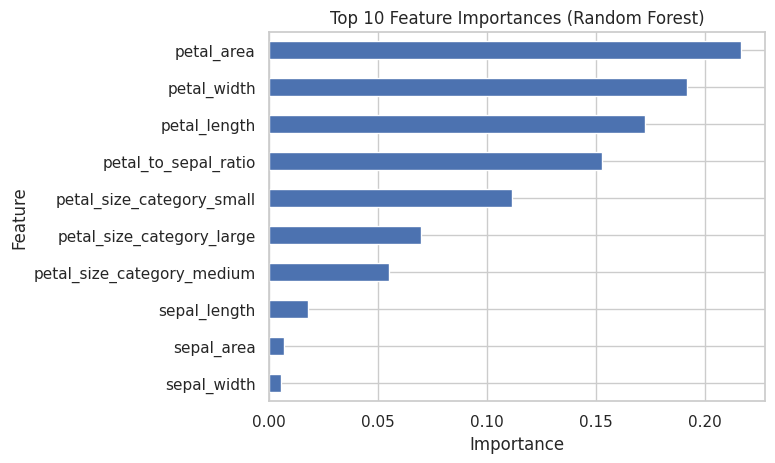

In [ ]:
plt.figure(figsize=(8,5))
top_n = min(15, len(fi))
fi.head(top_n).sort_values("importance").plot(kind="barh", x="feature", y="importance", legend=False)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


The feature-importance chart shows which original and engineered flower measurements contributed most to classification. Importance indicates predictive usefulness, not causation.

## 13. Optional: Feature selection using SelectFromModel

In [ ]:
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))

Accuracy (with feature selection): 0.9333

Classification Report (with feature selection):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



If performance remains similar, feature selection can simplify the feature space with little loss. If performance drops, useful information may have been removed.

## 14. Student Tasks

### Task 1
**Create one new engineered feature that you believe will help predict `species`. Write one paragraph justifying your choice.**

In [ ]:
# Task 1: New engineered feature
df_fe["petal_width_to_length_ratio"] = df_fe["petal_width"] / df_fe["petal_length"]

print("New feature created: petal_width_to_length_ratio")
display(df_fe[["petal_width", "petal_length", "petal_width_to_length_ratio", "species"]].head(10))

New feature created: petal_width_to_length_ratio


,petal_width,petal_length,petal_width_to_length_ratio,species
0,0.2,1.4,0.142857,setosa
1,0.2,1.4,0.142857,setosa
2,0.2,1.3,0.153846,setosa
3,0.2,1.5,0.133333,setosa
4,0.2,1.4,0.142857,setosa
5,0.4,1.7,0.235294,setosa
6,0.3,1.4,0.214286,setosa
7,0.2,1.5,0.133333,setosa
8,0.2,1.4,0.142857,setosa
9,0.1,1.5,0.066667,setosa


**Answer:** `petal_width_to_length_ratio` captures the shape of the petal rather than only its absolute size. Two flowers can have similar petal length but different widths, and the ratio represents that difference in a scale-independent way. Because Iris species differ strongly in petal characteristics, this engineered feature may provide additional information for classification.

### Task 2
**Try a different rule for the engineered categorical feature and discuss whether performance changes.**

The original task changes `is_peak_hour`; Iris has no time column, so the equivalent experiment changes the rule used to create the size-category feature.

In [ ]:
# Task 2: Alternative rule — use 4 equal-frequency petal-size categories
df_task2 = df.copy()
df_task2["petal_area"] = df_task2["petal_length"] * df_task2["petal_width"]
df_task2["petal_size_category"] = pd.qcut(
    df_task2["petal_area"], q=4,
    labels=["very_small", "small", "large", "very_large"],
    duplicates="drop"
)

X2 = df_task2.drop(columns=["species"])
y2 = df_task2["species"]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
cat2 = X2_train.select_dtypes(include=["object", "category"]).columns.tolist()
num2 = X2_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
pre2 = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat2), ("num", "passthrough", num2)])
model2 = Pipeline([("preprocess", pre2), ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"))])
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("Task 2 alternative-rule accuracy:", round(accuracy_score(y2_test, y2_pred), 4))
print(classification_report(y2_test, y2_pred))

Task 2 alternative-rule accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



**Discussion:** Compare this accuracy with the baseline accuracy above. A change in the discretization rule changes the categorical representation of petal size, so the model may gain or lose useful information. The better rule is the one that gives better test performance without relying on the test labels during feature construction.

### Task 3
**Change the number of categories used for the engineered size feature and compare accuracy and top feature importances.**

This is the Iris equivalent of changing `top_k` in the original `Item_Name_reduced` task.

In [ ]:
def evaluate_bins(n_bins):
    temp = df.copy()
    temp["petal_area"] = temp["petal_length"] * temp["petal_width"]
    labels = [f"bin_{i+1}" for i in range(n_bins)]
    temp["petal_size_category"] = pd.qcut(temp["petal_area"], q=n_bins, labels=labels, duplicates="drop")
    Xb = temp.drop(columns=["species"])
    yb = temp["species"]
    Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.2, random_state=42, stratify=yb)
    cb = Xtr.select_dtypes(include=["object", "category"]).columns.tolist()
    nb = Xtr.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    pb = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cb), ("num", "passthrough", nb)])
    mb = Pipeline([("preprocess", pb), ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"))])
    mb.fit(Xtr, ytr)
    pred = mb.predict(Xte)
    ohe_b = mb.named_steps["preprocess"].named_transformers_["cat"]
    names_b = np.concatenate([ohe_b.get_feature_names_out(cb) if cb else np.array([]), np.array(nb)])
    imp_b = mb.named_steps["rf"].feature_importances_
    fi_b = pd.DataFrame({"feature": names_b, "importance": imp_b}).sort_values("importance", ascending=False)
    return accuracy_score(yte, pred), fi_b.head(5)

results = []
for bins in [2, 3, 4, 5]:
    acc, topfi = evaluate_bins(bins)
    results.append({"number_of_bins": bins, "accuracy": acc, "top_features": ", ".join(topfi["feature"].tolist())})

task3_results = pd.DataFrame(results)
display(task3_results)

,number_of_bins,accuracy,top_features
0,2,0.966667,"petal_area, petal_width, petal_length, sepal_l..."
1,3,0.933333,"petal_area, petal_length, petal_width, petal_s..."
2,4,0.966667,"petal_area, petal_length, petal_width, petal_s..."
3,5,0.966667,"petal_area, petal_width, petal_length, sepal_l..."


**Answer:** The table above provides the required comparison. Use the row with the highest test accuracy as the best-performing binning rule for this run, and compare the listed top features to see how feature importance changes when the categorical representation changes.

### Task 4
**Run the optional feature-selection section and explain whether it was beneficial.**

In [ ]:
# Task 4: Compare baseline and feature-selection accuracy
baseline_acc = accuracy_score(y_test, y_pred)
selected_acc = accuracy_score(y_test, y_pred_fs)

print("Baseline accuracy:", round(baseline_acc, 4))
print("Feature-selection accuracy:", round(selected_acc, 4))
print("Accuracy change:", round(selected_acc - baseline_acc, 4))

Baseline accuracy: 0.9667
Feature-selection accuracy: 0.9333
Accuracy change: -0.0333


**Answer:** Feature selection is beneficial if the selected model keeps similar or better accuracy while using fewer transformed features. If accuracy decreases, the selection threshold removed information that was useful for distinguishing the Iris species. The printed comparison above gives the result for this dataset and split.

### Task 5
**Compare the baseline model with the engineered-feature model and state whether feature engineering improved the classification result.**

This final comparison summarizes the effect of the Lab 5 workflow on the different Iris dataset.

In [ ]:
# Task 5: baseline using original Iris measurements only
X_base = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y_base = df["species"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)
base_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample")
base_model.fit(Xb_train, yb_train)
yb_pred = base_model.predict(Xb_test)

print("Original-features accuracy:", round(accuracy_score(yb_test, yb_pred), 4))
print("Engineered-features accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Difference:", round(accuracy_score(y_test, y_pred) - accuracy_score(yb_test, yb_pred), 4))

Original-features accuracy: 0.9
Engineered-features accuracy: 0.9667
Difference: 0.0667


**Answer:** Feature engineering should be judged by the test-set comparison above. If the engineered model has higher accuracy, the added features improved predictive performance for this split. If it is equal or lower, the engineered features did not provide additional useful signal beyond the original Iris measurements.